# Blender — XGBoost + LightGBM

Loads OOF predictions from both models, finds the optimal linear blend weight on OOF (since both models share identical CV splits), applies the same weight to test predictions, and saves a final submission using the standard numbering scheme.

**Run order:** `xgboost.ipynb` and `lightgbm.ipynb` first, then this notebook.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (10, 5)

from sklearn.metrics import roc_auc_score

from common import find_next_submission_file, find_last_submission_file

## Load OOF predictions

In [2]:
xgb_oof_df = pd.read_csv('./archive/xgb_oof.csv')
lgbm_oof_df = pd.read_csv('./archive/lgbm_oof.csv')

assert len(xgb_oof_df) == len(lgbm_oof_df), 'OOF files length mismatch'
assert np.array_equal(xgb_oof_df['y'].values, lgbm_oof_df['y'].values), 'OOF labels mismatch — were both notebooks run with the same splits?'

y_oof = xgb_oof_df['y'].values
xgb_oof = xgb_oof_df['oof'].values
lgbm_oof = lgbm_oof_df['oof'].values

print(f'rows: {len(y_oof)}')
print(f'XGBoost OOF AUC:  {roc_auc_score(y_oof, xgb_oof):.5f}')
print(f'LightGBM OOF AUC: {roc_auc_score(y_oof, lgbm_oof):.5f}')
print(f'Pred correlation: {np.corrcoef(xgb_oof, lgbm_oof)[0, 1]:.4f}')

rows: 439140
XGBoost OOF AUC:  0.92814
LightGBM OOF AUC: 0.93076
Pred correlation: 0.9716


## Find optimal blend weight

Grid search over `alpha` where blended = `alpha * xgb + (1 - alpha) * lgbm`. Pick alpha that maximizes OOF AUC.

In [3]:
alphas = np.linspace(0, 1, 101)
aucs = [roc_auc_score(y_oof, a * xgb_oof + (1 - a) * lgbm_oof) for a in alphas]

best_idx = int(np.argmax(aucs))
best_alpha = float(alphas[best_idx])
best_auc = float(aucs[best_idx])

print(f'Optimal blend: {best_alpha:.2f} * xgb + {1 - best_alpha:.2f} * lgbm')
print(f'Blended OOF AUC: {best_auc:.5f}')
print(f'Improvement vs best single model: {best_auc - max(roc_auc_score(y_oof, xgb_oof), roc_auc_score(y_oof, lgbm_oof)):+.5f}')

Optimal blend: 0.30 * xgb + 0.70 * lgbm
Blended OOF AUC: 0.93152
Improvement vs best single model: +0.00076


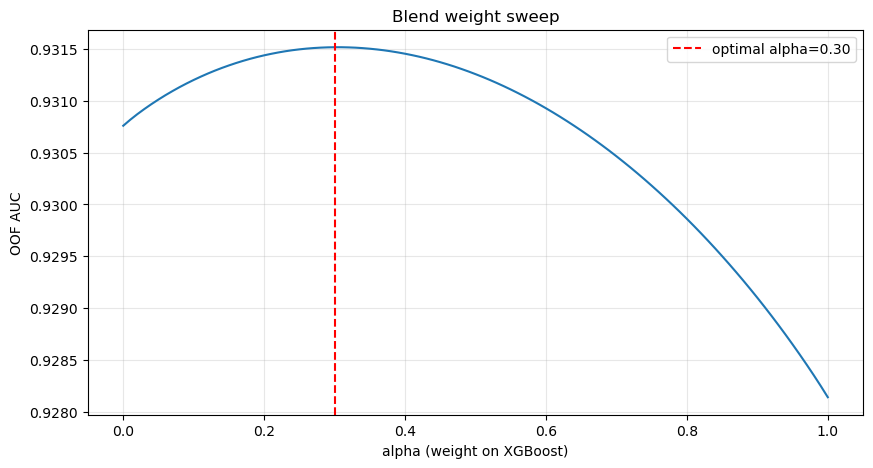

In [4]:
plt.plot(alphas, aucs)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'optimal alpha={best_alpha:.2f}')
plt.xlabel('alpha (weight on XGBoost)')
plt.ylabel('OOF AUC')
plt.title('Blend weight sweep')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Load test predictions and blend

In [5]:
xgb_test_df = pd.read_csv('./archive/xgb_test.csv')
lgbm_test_df = pd.read_csv('./archive/lgbm_test.csv')

assert len(xgb_test_df) == len(lgbm_test_df), 'test pred lengths mismatch'
assert np.array_equal(xgb_test_df['id'].values, lgbm_test_df['id'].values), 'test pred IDs mismatch'

blended_preds = best_alpha * xgb_test_df['pred'].values + (1 - best_alpha) * lgbm_test_df['pred'].values

submission_df = pd.DataFrame({
    'id': xgb_test_df['id'].values,
    'PitNextLap': blended_preds,
})

submission_df.head()

,id,PitNextLap
0,439140,0.005720
1,439141,0.005236
2,439142,0.005930
3,439143,0.220099
4,439144,0.911870


In [6]:
submission_df['PitNextLap'].describe()

count    188165.000000
mean          0.199338
std           0.303048
min           0.000009
25%           0.002290
50%           0.019062
75%           0.320924
max           0.996418
Name: PitNextLap, dtype: float64

## Save submission

Uses the same `submission_NN.csv` numbering as the single-model notebooks. Skips save if identical to the last submission.

In [7]:
from glob import glob
existing_subs = sorted(glob('./archive/submission_*.csv'))
last_submission = pd.read_csv(existing_subs[-1]) if existing_subs else None

In [8]:
if (
    last_submission is not None
    and 'PitNextLap' in last_submission.columns
    and len(last_submission) == len(submission_df)
    and np.allclose(last_submission['PitNextLap'], submission_df['PitNextLap'], rtol=1e-5)
):
    print('skipping save (identical to last submission)')
else:
    out = find_next_submission_file() if last_submission is not None else './archive/submission_01.csv'
    submission_df.to_csv(out, index=False)
    print(f'saved {out}')

saved ./archive/submission_24.csv
